**Question 1**

Its high noon two cowboys (or players) engage in the following duel. the two cowboys stand on the real line, cowboy I at the point $-1$, and cowboy II at the point $1$. They each have one bullet in their gun. They start walking towards each other at the same rate, deciding when to take a shot. Their gun is equipped with a silencer so they cannot hear when the other takes a shot, so each has to decide independently when to take a shot. The chance either cowboy hits is equal to the distance they have walked so far. Specifically, if cowboy I takes a shot after walking a distance $x$ (from -1 towards 0) cowboy's I shot hits with probability $x$. Likewise cowboy II after walking distance $y$ (from +1 towards 0) has a probability to hit with their shot of $y$. If one cowboy hits the other, without being hit in return they get a payoff of 1. conversely if a cowboy is hit without scoring a hit themselves, they get a payoff of -1. In all other cases (both hit, both miss) the dual is considered a draw and the payoff to both players is $0$.

This is a two person zero sum game  as we have discussed in class, except that the action spaces of the two players are \emph{continuous}: each action is a real number in the unit interval [0,1] and represents the distance travelled before taking a shot. In this problem, we will (mostly) deal with a discretized approximate version of the game where the action spaces are finite, so it becomes a usual game with finite action spaces as we have discussed. 

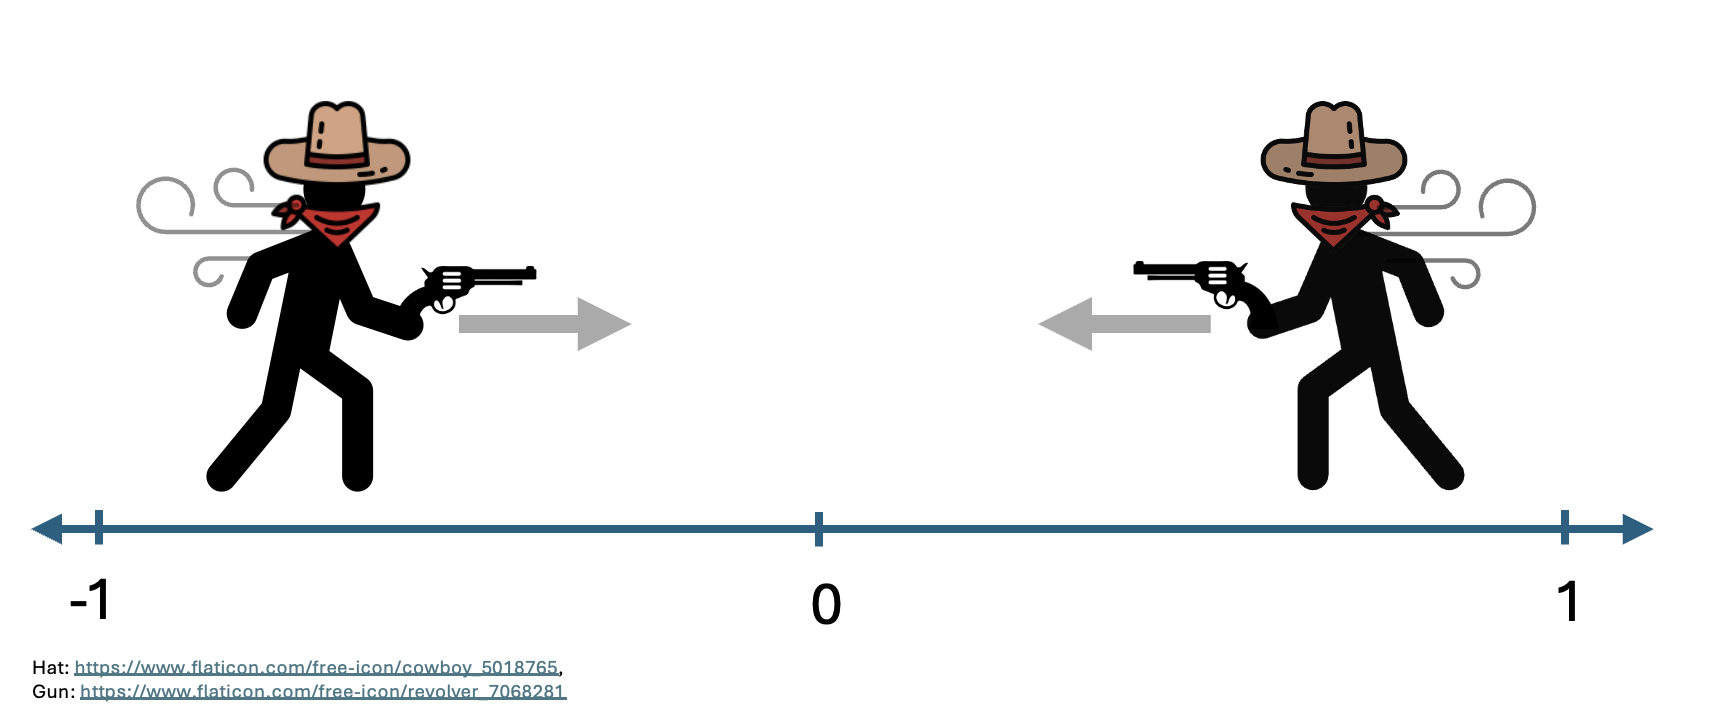

1. (2 points) Derive the pay off function $M(x,y)$ based on the problem description:
* [$x<y$] In this case cowboy I fires first and he either hits cowboy II with probability $x$ and hence gets payoff $1$ or he misses and then cowboy II shoots and hits cowboy I with probability $y$ so the payoff to cowboy I is $-1$. Derive the expected payoff to cowboy I.
* [$y<x$] Now derive the expected payoff when cowboy I shoots second.
* [$x=y$] Finally derive the expected payoff when both cowboys shoot at the same time.

##### *Answer:*
If $x < y$, meaning cowboy I fires first, there are three possible outcomes:
- Cowboy I hits; probability $x$ with payout $1$.
- Cowboy I misses, cowboy II hits; probability $(1-x)y$ with payout $-1$.
- Both miss; probability $(1-x)(1-y)$ with payout $0$.
Pay off function for cowboy I thus becomes: 
$$
M(x, y) = (x * 1) + ((1 - x)y * -1) + ((1-x)(1-y)*0) = x - y + xy
$$

If $y < x$, meaning cowboy II fires first, there are three possible outcomes:
- Cowboy II hits; probability $y$ with payout $-1$.
- Cowboy II misses, cowboy I hits; probability $(1-y)x$ with payout $1$.
- Both miss; probability $(1-x)(1-y)$ with payout $0$.
Pay off function for cowboy I thus becomes: 
$$
M(x, y) = (y * -1) + ((1 - y)x * 1) + ((1-x)(1-y)*0) = x - y - xy
$$

If $x = y$, meaning cowboy I and cowboy II fire simultaneously, there are three possible outcomes:
- Cowboy I hits, cowboy II misses; probability $x(1 - y)$ with payout $1$.
- Cowboy I misses, cowboy II hits; probability $(1 - x)y$ with payout $-1$.
- Both hits/miss; Irrelevant as payout is $0$.
Pay off function for cowboy I thus becomes: 
$$
\begin{aligned}
M(x, y) = (x(1 - y) * 1) + ((1 - x)y * -1) = x - xy - y + xy \\ = x - y 
\iff 0, \ \text{as} \ x=y
\end{aligned}
$$

2. (3 points) Discretize the problem by considering a grid to divide each interval $[-1,0]$ and $[0,1]$ by placing $n-2$ equally spaced points with $n \geq 2$ (so that there are $n$ possible strategies for each player). Now we have a finite payoff matrix $A^{(n)}[i,j]$ with both $i,j$ ranging over $\{1,\cdots,n\}$. Now Compute by hand, optimal strategies for $n=2$ and $n=3$.

##### *Answer:*
With $n = 2$, the action space for both cowboys is $\{0, 1\}$. The payoff matrix can be populated by using the payoff function derived in the previous question:
$$
\begin{aligned}
&A_{1, 1}: M(0, 0) = 0 \\
&A_{1, 2}: M(0, 1) = -1 \\
&A_{2, 1}: M(1, 0) = 1 \\
&A_{2, 2}: M(1, 1) = 0 \\
\end{aligned}
$$
Final matrix:
$$
A^{(2)} = 
\begin{pmatrix}
0 & -1 \\ 1 & 0
\end{pmatrix}
$$
As cowboy I has their choices represented by the rows, their best strategy is strategy 2: picking $x = 1$. Cowboy II has their choices represented by the columns, and as the matrix is the expected payoff for cowboy I, cowboy II wants to pick the column minimizing the expected payoff for cowboy I. Therefore, their best strategy is strategy 2: picking $y = 1$. The value of the game is thus $0$.

This makes perfect sense, because why ever choose a probability to hit of $0$.

With $n = 3$, the action space for both cowboys is $\{0, \frac{1}{2}, 1\}$. The payoff matrix can be populated by using the payoff function derived in the previous question:
$$
\begin{aligned}
&A_{1, 1}: M(0, 0) = 0 \\
&A_{1, 2}: M(0, \frac{1}{2}) = -\frac{1}{2} \\
&A_{1, 3}: M(0, 1) = -1 \\
&A_{2, 1}: M(\frac{1}{2}, 0) = -\frac{1}{2} \\
&A_{2, 2}: M(\frac{1}{2}, \frac{1}{2}) = 0 \\
&A_{2, 3}: M(\frac{1}{2}, 1) = 0 \\
&A_{3, 1}: M(1, 0) = 1 \\
&A_{3, 2}: M(1, \frac{1}{2}) = 0 \\
&A_{3, 3}: M(1, 1) = 0 \\
\end{aligned}
$$
Final matrix:
$$
A^{(3)} = 
\begin{pmatrix}
0 & -\frac{1}{2} & -1 \\ 
\frac{1}{2} & 0 & 0 \\ 
1 & 0 & 0
\end{pmatrix}
$$

With the same explanation as above, cowboy I should choose strategy 3: picking $x = 1$. Likewise, cowboy II should also choose strategy 3: picking $y = 1$. 

3. (2 points) Using the finite payoff matrix $A^{(n)}$, write a LP to compute optimal strategies for both players.

##### *Answer:*
Let: $z$ be the expected value of the game; $\vec{p} = (p_1, ..., p_n)$ the probabilities of each respective strategy for cowboy I; $\vec{q} = (q_1, ..., q_n)$ the probabilities of each respective strategy for cowboy II.

Cowboy I wants to find a probability distribution $p$ that maximizes the expected payout of $z$, where $\sum {p} = 1$ in order for $\vec{p}$ to be a valid probability distribution. The expected payoff against any of cowboy II's strategies must be at least $z$ to secure a minimum expected payoff of $z$ (assuming cowboy II plays optimally). The LP becomes:
$$
\begin{aligned}
\text{max} \quad & z \\
\text{s.t.} \quad & \sum_{i=1}^n p_i A_{i, j}^{(n)} \ge z, 
\quad \text{for all} \ j \in \{1, ..., n\} \\
& \sum_{i=1}^n p_i = 1 \\
& \vec{p} \ge 0
\end{aligned}
$$

4. (3 points) Use the cvxpy LP solver to compute the optimum strategies for both players and plot it on a graph, for $n=10, 100, 1000$. 

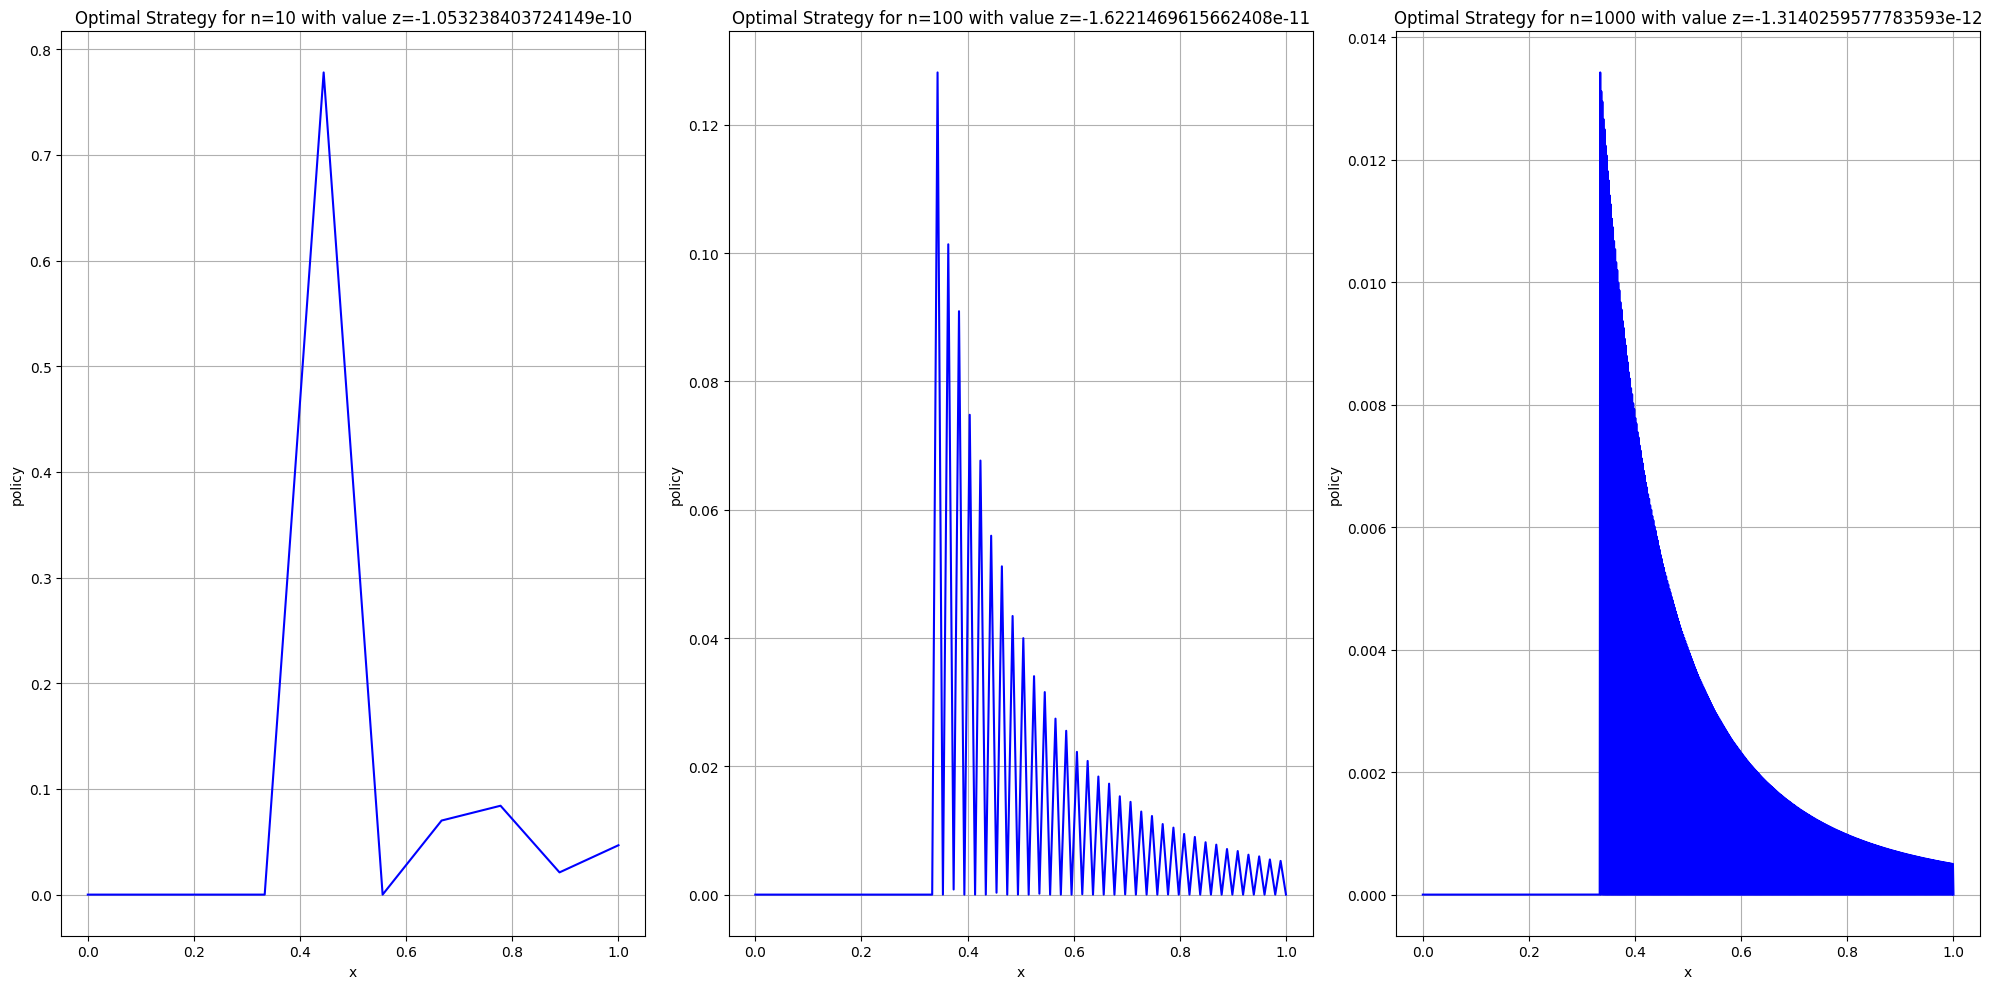

In [1]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt

def solve(n):
    # [0, ..., 1] action space
    x = [i / (n - 1) for i in range(n)]

    # payoff matrix
    A = []
    for i in range(n):
        row = []
        for j in range(n):
            if i < j:
                # Cowboy I shoots first
                val = x[i] - x[j] + x[i] * x[j]
            elif i > j:
                # Cowboy II shoots first
                val = x[i] - x[j] - x[i] * x[j]
            else:
                val = 0.0
            row.append(val)
        A.append(row)

    # to use @ notation
    A = np.array(A)

    # policy
    p = cp.Variable(n)
    z = cp.Variable()

    obj = cp.Maximize(z)

    const = [
        A.T @ p >= z,
        cp.sum(p) == 1,
        p >= 0
    ]

    prob = cp.Problem(obj, const)
    prob.solve()

    return x, p.value, z.value

n_list = [10, 100, 1000]
plt.figure(figsize=(20, 10))

for i, n in enumerate(n_list, start=1):
    x, p, z = solve(n)

    plt.subplot(1, 3, i)
    plt.plot(x, p, color='blue')
    plt.title(f"Optimal Strategy for n={n} with value z={z}")
    plt.xlabel("x")
    plt.ylabel("policy")
    plt.grid(True)

plt.tight_layout()
plt.show()

5. (3 points) Using your finite approximations fit a continuous curve (using suitable regression tools) to estimate the function that is the solution for the continuous case. Optional (0 points) compute the solution analytically to check your answer.

b = 3.0010650706243354
C = 0.4996186948155631


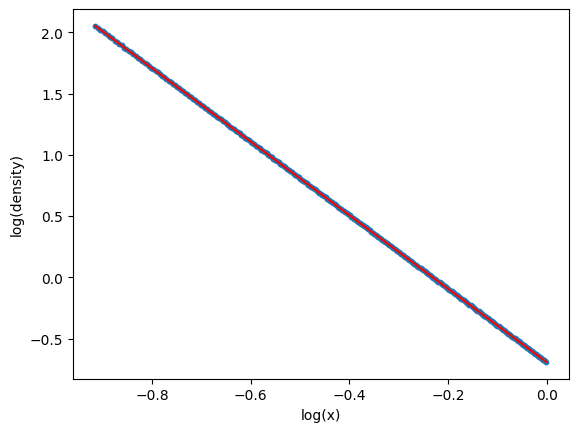

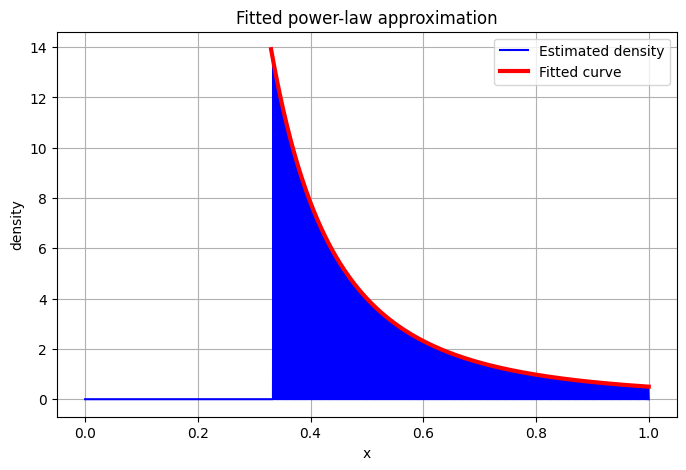

In [18]:
from sklearn.linear_model import LinearRegression
import numpy as np

dx = x[1] - x[0]
density = p / dx

x = np.array(x)
density = np.array(density)

mask = density > 1e-3   # keep only spikes
x_fit = x[mask]
y_fit = density[mask]

mask2 = x_fit > 0.4   # avoid boundary
X = np.log(x_fit[mask2]).reshape(-1,1)
Y = np.log(y_fit[mask2])

reg = LinearRegression().fit(X,Y)

b = -reg.coef_[0]
C = np.exp(reg.intercept_)

print("b =", b)
print("C =", C)

plt.scatter(np.log(x_fit[mask2]), np.log(y_fit[mask2]), s=10)
plt.plot(np.log(x_fit[mask2]), reg.predict(X), color="red")
plt.xlabel("log(x)")
plt.ylabel("log(density)")


# create smooth x values
x_dense = np.linspace(0.33, 1, 500)

# fitted curve
y_fit = C / (x_dense**b)

plt.figure(figsize=(8,5))

# original estimated density
plt.plot(x, density, label="Estimated density", color="blue")

# fitted power-law curve
plt.plot(x_dense, y_fit, label="Fitted curve", color="red", linewidth=3)

plt.xlabel("x")
plt.ylabel("density")
plt.title("Fitted power-law approximation")
plt.legend()
plt.grid(True)

plt.show()

6. (2 points) Show rigorously that the strategies you guessed in (5) for the continuous setting constitute a Nash equilibrium. Could there be other Nash equilibria?

##### *Answer:*
SKIPPED

7. (2 points) Suppose the guns are not silenced so if a cowboy hears the other gun and survives, he can just wait until he reaches $0$ and then shoot to hit the other guy with certainty. What are the optimal strategies now?

##### *Answer:*